# Extrapolation validation of GPQR models for H

This notebook visualizes extrapolation performance of models with and without physical priors.

Models with constant prior show inferior extrapolation performance.

In [ ]:
import sys
import os
import math

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from scripts.model_selection.cv import (
    split_extrapolate_data,
    cross_validate,
    cross_validate_gpr,
)

QUANTILES = torch.tensor([0.05, 0.25, 0.5, 0.75, 0.95]).to(device)
CENTER_QUANTILE_INDEX = 2
NUM_LOWER_QUANTILES = 2
NUM_LATENTS = len(QUANTILES)
NUM_LOWER_LATENTS = NUM_LATENTS // 2

N_EPOCHS = int(os.getenv("HEAVYEDGE_N_EPOCHS", 10000))

X = pd.read_csv("../_temp/X.csv").drop(columns="Slurry").values
y = pd.read_csv("../_temp/y.csv")["H"].values

x_train_ev, y_train_ev, x_test_ev, y_test_ev, x_scales_ev, x_mins_ev = (
    split_extrapolate_data(X, y, 0.8, device)
)

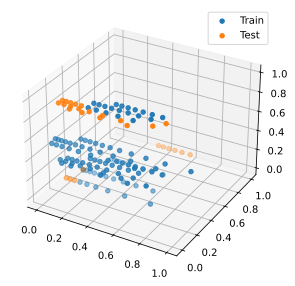

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(
    x_train_ev[0, :, 0].cpu(),
    x_train_ev[0, :, 1].cpu(),
    x_train_ev[0, :, 2].cpu(),
    label="Train",
)
ax.scatter(
    x_test_ev[0, :, 0].cpu(),
    x_test_ev[0, :, 1].cpu(),
    x_test_ev[0, :, 2].cpu(),
    label="Test",
)
ax.legend()
plt.show()

## Basic GPR

In [ ]:
from scripts.all_models import GPR_H
from gpytorch.likelihoods import GaussianLikelihood

CV_PATH = "../_temp/gpr_ev.H.csv"

if os.path.exists(CV_PATH):
    gpr_ev = pd.read_csv(CV_PATH).values
else:
    likelihood = GaussianLikelihood(batch_shape=torch.Size([1])).to(device)
    gpr = GPR_H(
        x_train_ev.clone().detach(),
        y_train_ev.clone().detach(),
        likelihood,
        X_scale=x_scales_ev,
        X_min=x_mins_ev,
        batch_shape=torch.Size([1]),
    ).to(device)

    gpr_ev = cross_validate_gpr(
        x_train_ev,
        y_train_ev,
        x_test_ev,
        y_test_ev,
        QUANTILES,
        gpr,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(gpr_ev).to_csv(CV_PATH, index=False)

In [ ]:
from scripts.all_models import GPR_H_ConstantMean
from gpytorch.likelihoods import GaussianLikelihood

CV_PATH = "../_temp/gpr_cm_ev.H.csv"

if os.path.exists(CV_PATH):
    gpr_cm_ev = pd.read_csv(CV_PATH).values
else:
    likelihood = GaussianLikelihood(batch_shape=torch.Size([1])).to(device)
    gpr_cm = GPR_H_ConstantMean(
        x_train_ev.clone().detach(),
        y_train_ev.clone().detach(),
        likelihood,
        batch_shape=torch.Size([1]),
    ).to(device)

    gpr_cm_ev = cross_validate_gpr(
        x_train_ev,
        y_train_ev,
        x_test_ev,
        y_test_ev,
        QUANTILES,
        gpr_cm,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(gpr_cm_ev).to_csv(CV_PATH, index=False)

## Center-gap LMC

In [ ]:
from scripts.all_models import CgLmcMtgpqr_H
from gpytorch_qr.likelihoods import MultitaskCenterGapQuantileGPLikelihood

CV_PATH = "../_temp/cg_lmc_ev.H.csv"

if os.path.exists(CV_PATH):
    cg_lmc_ev = pd.read_csv(CV_PATH).values
else:
    cg_lmc_mtgpqr = CgLmcMtgpqr_H(
        inducing_points=x_train_ev.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=x_scales_ev,
        X_min=x_mins_ev,
        batch_shape=torch.Size([1]),
    ).to(device)
    likelihood = MultitaskCenterGapQuantileGPLikelihood(
        QUANTILES.unsqueeze(0),
        CENTER_QUANTILE_INDEX,
        torch.zeros((1, len(QUANTILES))),
        learn_scales=True,
    ).to(device)

    cg_lmc_ev = cross_validate(
        x_train_ev,
        y_train_ev,
        x_test_ev,
        y_test_ev,
        QUANTILES,
        cg_lmc_mtgpqr,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(cg_lmc_ev).to_csv(CV_PATH, index=False)

In [ ]:
from scripts.all_models import CgLmcMtgpqr_H_ConstantMean
from gpytorch_qr.likelihoods import MultitaskCenterGapQuantileGPLikelihood

CV_PATH = "../_temp/cg_lmc_cm_ev.H.csv"

if os.path.exists(CV_PATH):
    cg_lmc_cm_ev = pd.read_csv(CV_PATH).values
else:
    cg_lmc_mtgpqr_cm = CgLmcMtgpqr_H_ConstantMean(
        inducing_points=x_train_ev.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=x_scales_ev,
        X_min=x_mins_ev,
        batch_shape=torch.Size([1]),
    ).to(device)
    likelihood = MultitaskCenterGapQuantileGPLikelihood(
        QUANTILES.unsqueeze(0),
        CENTER_QUANTILE_INDEX,
        torch.zeros((1, len(QUANTILES))),
        learn_scales=True,
    ).to(device)

    cg_lmc_cm_ev = cross_validate(
        x_train_ev,
        y_train_ev,
        x_test_ev,
        y_test_ev,
        QUANTILES,
        cg_lmc_mtgpqr_cm,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(cg_lmc_cm_ev).to_csv(CV_PATH, index=False)

## Center-gap independent

In [ ]:
from scripts.all_models import CgIndependentMtgpqr_H
from gpytorch_qr.likelihoods import MultitaskCenterGapQuantileGPLikelihood

CV_PATH = "../_temp/cg_independent_ev.H.csv"

if os.path.exists(CV_PATH):
    cg_independent_ev = pd.read_csv(CV_PATH).values
else:
    cg_independent_mtgpqr = CgIndependentMtgpqr_H(
        inducing_points=x_train_ev.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=x_scales_ev,
        X_min=x_mins_ev,
        batch_shape=torch.Size([1]),
    ).to(device)
    likelihood = MultitaskCenterGapQuantileGPLikelihood(
        QUANTILES.unsqueeze(0),
        CENTER_QUANTILE_INDEX,
        torch.zeros((1, len(QUANTILES))),
        learn_scales=True,
    ).to(device)

    cg_independent_ev = cross_validate(
        x_train_ev,
        y_train_ev,
        x_test_ev,
        y_test_ev,
        QUANTILES,
        cg_independent_mtgpqr,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(cg_independent_ev).to_csv(CV_PATH, index=False)

In [ ]:
from scripts.all_models import CgIndependentMtgpqr_H_ConstantMean
from gpytorch_qr.likelihoods import MultitaskCenterGapQuantileGPLikelihood

CV_PATH = "../_temp/cg_independent_cm_ev.H.csv"

if os.path.exists(CV_PATH):
    cg_independent_cm_ev = pd.read_csv(CV_PATH).values
else:
    cg_independent_mtgpqr_cm = CgIndependentMtgpqr_H_ConstantMean(
        inducing_points=x_train_ev.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=x_scales_ev,
        X_min=x_mins_ev,
        batch_shape=torch.Size([1]),
    ).to(device)
    likelihood = MultitaskCenterGapQuantileGPLikelihood(
        QUANTILES.unsqueeze(0),
        CENTER_QUANTILE_INDEX,
        torch.zeros((1, len(QUANTILES))),
        learn_scales=True,
    ).to(device)

    cg_independent_cm_ev = cross_validate(
        x_train_ev,
        y_train_ev,
        x_test_ev,
        y_test_ev,
        QUANTILES,
        cg_independent_mtgpqr_cm,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(cg_independent_cm_ev).to_csv(CV_PATH, index=False)

## Direct LMC

In [ ]:
from scripts.all_models import DirectLmcMtgpqr_H
from gpytorch_qr.likelihoods import MultitaskQuantileGPLikelihood

CV_PATH = "../_temp/direct_lmc_ev.H.csv"

if os.path.exists(CV_PATH):
    direct_lmc_ev = pd.read_csv(CV_PATH).values
else:
    direct_lmc_mtgpqr = DirectLmcMtgpqr_H(
        inducing_points=x_train_ev.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=x_scales_ev,
        X_min=x_mins_ev,
        batch_shape=torch.Size([1]),
    ).to(device)
    likelihood = MultitaskQuantileGPLikelihood(
        QUANTILES.unsqueeze(0),
        torch.zeros((1, len(QUANTILES))),
        learn_scales=True,
    ).to(device)

    direct_lmc_ev = cross_validate(
        x_train_ev,
        y_train_ev,
        x_test_ev,
        y_test_ev,
        QUANTILES,
        direct_lmc_mtgpqr,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(direct_lmc_ev).to_csv(CV_PATH, index=False)

In [ ]:
from scripts.all_models import DirectLmcMtgpqr_H_ConstantMean
from gpytorch_qr.likelihoods import MultitaskQuantileGPLikelihood

CV_PATH = "../_temp/direct_lmc_cm_ev.H.csv"

if os.path.exists(CV_PATH):
    direct_lmc_cm_ev = pd.read_csv(CV_PATH).values
else:
    direct_lmc_mtgpqr_cm = DirectLmcMtgpqr_H_ConstantMean(
        inducing_points=x_train_ev.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=x_scales_ev,
        X_min=x_mins_ev,
        batch_shape=torch.Size([1]),
    ).to(device)
    likelihood = MultitaskQuantileGPLikelihood(
        QUANTILES.unsqueeze(0),
        torch.zeros((1, len(QUANTILES))),
        learn_scales=True,
    ).to(device)

    direct_lmc_cm_ev = cross_validate(
        x_train_ev,
        y_train_ev,
        x_test_ev,
        y_test_ev,
        QUANTILES,
        direct_lmc_mtgpqr_cm,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(direct_lmc_cm_ev).to_csv(CV_PATH, index=False)

## Direct independent

In [ ]:
from scripts.all_models import DirectIndependentMtgpqr_H
from gpytorch_qr.likelihoods import MultitaskQuantileGPLikelihood

CV_PATH = "../_temp/direct_independent_ev.H.csv"

if os.path.exists(CV_PATH):
    direct_independent_ev = pd.read_csv(CV_PATH).values
else:
    direct_independent_mtgpqr = DirectIndependentMtgpqr_H(
        inducing_points=x_train_ev.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=x_scales_ev,
        X_min=x_mins_ev,
        batch_shape=torch.Size([1]),
    ).to(device)
    likelihood = MultitaskQuantileGPLikelihood(
        QUANTILES.unsqueeze(0),
        torch.zeros((1, len(QUANTILES))),
        learn_scales=True,
    ).to(device)

    direct_independent_ev = cross_validate(
        x_train_ev,
        y_train_ev,
        x_test_ev,
        y_test_ev,
        QUANTILES,
        direct_independent_mtgpqr,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(direct_independent_ev).to_csv(CV_PATH, index=False)

In [ ]:
from scripts.all_models import DirectIndependentMtgpqr_H_ConstantMean
from gpytorch_qr.likelihoods import MultitaskQuantileGPLikelihood

CV_PATH = "../_temp/direct_independent_cm_ev.H.csv"

if os.path.exists(CV_PATH):
    direct_independent_cm_ev = pd.read_csv(CV_PATH).values
else:
    direct_independent_mtgpqr_cm = DirectIndependentMtgpqr_H_ConstantMean(
        inducing_points=x_train_ev.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=x_scales_ev,
        X_min=x_mins_ev,
        batch_shape=torch.Size([1]),
    ).to(device)
    likelihood = MultitaskQuantileGPLikelihood(
        QUANTILES.unsqueeze(0),
        torch.zeros((1, len(QUANTILES))),
        learn_scales=True,
    ).to(device)

    direct_independent_cm_ev = cross_validate(
        x_train_ev,
        y_train_ev,
        x_test_ev,
        y_test_ev,
        QUANTILES,
        direct_independent_mtgpqr_cm,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(direct_independent_cm_ev).to_csv(CV_PATH, index=False)

## Plot

In [ ]:
def sci_label(value: float, precision: int = 2) -> str:
    if value == 0:
        return f"{0:.{precision}f} × 10^0"
    exponent = math.floor(math.log10(abs(value)))
    mantissa = value / (10**exponent)
    return f"{mantissa:.{precision}f} × 10^{exponent}"

### Loss by epoch

In [ ]:
plt.plot(gpr_ev.mean(axis=1), label="GPR")
plt.plot(gpr_cm_ev.mean(axis=1), label="GPR CM")
plt.plot(cg_lmc_ev.mean(axis=1), label="Cg Lmc")
plt.plot(cg_lmc_cm_ev.mean(axis=1), label="Cg Lmc CM")
plt.plot(cg_independent_ev.mean(axis=1), label="Cg Independent")
plt.plot(cg_independent_cm_ev.mean(axis=1), label="Cg Independent CM")
plt.plot(direct_lmc_ev.mean(axis=1), label="Direct Lmc")
plt.plot(direct_lmc_cm_ev.mean(axis=1), label="Direct Lmc CM")
plt.plot(direct_independent_ev.mean(axis=1), label="Direct Independent")
plt.plot(direct_independent_cm_ev.mean(axis=1), label="Direct Independent CM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Extrapolation loss by epoch")
plt.legend()
plt.show()

### Minimum loss

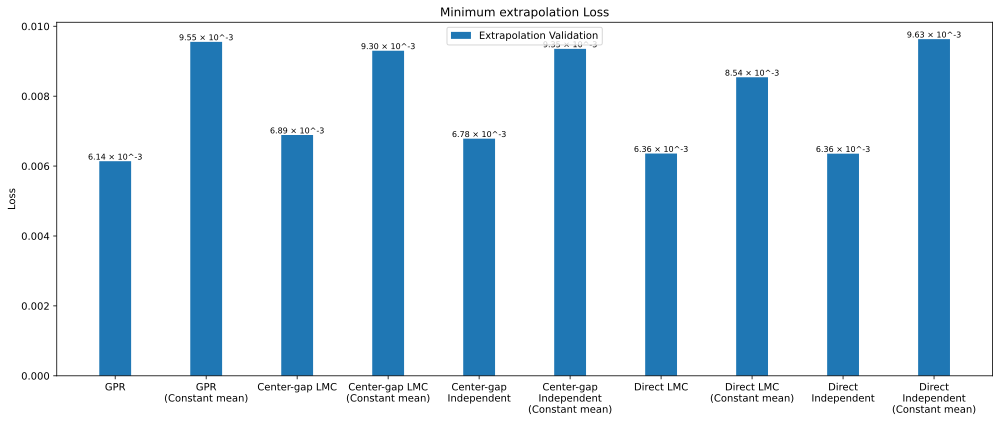

In [ ]:
names = [
    "GPR",
    "GPR\n(Constant mean)",
    "Center-gap LMC",
    "Center-gap LMC\n(Constant mean)",
    "Center-gap\nIndependent",
    "Center-gap\nIndependent\n(Constant mean)",
    "Direct LMC",
    "Direct LMC\n(Constant mean)",
    "Direct\nIndependent",
    "Direct\nIndependent\n(Constant mean)",
]
ev_losses = [
    gpr_ev.mean(axis=1).min(),
    gpr_cm_ev.mean(axis=1).min(),
    cg_lmc_ev.mean(axis=1).min(),
    cg_lmc_cm_ev.mean(axis=1).min(),
    cg_independent_ev.mean(axis=1).min(),
    cg_independent_cm_ev.mean(axis=1).min(),
    direct_lmc_ev.mean(axis=1).min(),
    direct_lmc_cm_ev.mean(axis=1).min(),
    direct_independent_ev.mean(axis=1).min(),
    direct_independent_cm_ev.mean(axis=1).min(),
]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars_ev = ax.bar(x, ev_losses, width, label="Extrapolation Validation")

for bar in list(bars_ev):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        sci_label(height),
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Loss")
ax.set_title("Minimum extrapolation Loss")
ax.legend()
plt.tight_layout()
plt.show()